In [1]:
import torch
import sys
print("Interpreter:", sys.executable)
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Interpreter: d:\maga25\NIR\.venv\Scripts\python.exe
CUDA available: False
GPU name: No GPU


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используемое устройство: {device}")
if device.type == 'cuda':
    print(f"Видеокарта: {torch.cuda.get_device_name(0)}")
    print(f"Всего видеопамяти: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Используемое устройство: cpu


In [3]:
# Standard
import random

import numpy as np
import pandas as pd
import torch

# Third Party
from transformers import (
    EarlyStoppingCallback,
    PatchTSTConfig,
    PatchTSTForPrediction,
    Trainer,
    TrainingArguments,
)

# First Party
from tsfm_public.toolkit.dataset import ForecastDFDataset
from tsfm_public.toolkit.time_series_preprocessor import TimeSeriesPreprocessor
from tsfm_public.toolkit.util import select_by_index

d:\maga25\NIR\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Set seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [5]:
dataset = "./ETTh1.csv"
num_workers = 8  # Reduce this if you have low number of CPU cores
batch_size = 32  # Reduce if not enough GPU memory available
context_length = 512
forecast_horizon = 96
patch_length = 12

In [6]:
print(f"Loading target dataset: {dataset}")
dataset_path = f"https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/{dataset}.csv"
timestamp_column = "date"
id_columns = []
forecast_columns = ["HUFL", "HULL", "MUFL", "MULL", "LUFL", "LULL", "OT"]
train_start_index = None  # None indicates beginning of dataset
train_end_index = 12 * 30 * 24

# we shift the start of the validation/test period back by context length so that
# the first validation/test timestamp is immediately following the training data
valid_start_index = 12 * 30 * 24 - context_length
valid_end_index = 12 * 30 * 24 + 4 * 30 * 24

test_start_index = 12 * 30 * 24 + 4 * 30 * 24 - context_length
test_end_index = 12 * 30 * 24 + 8 * 30 * 24

Loading target dataset: ./ETTh1.csv


In [7]:
data = pd.read_csv(
    dataset,
    parse_dates=[timestamp_column],
)

train_data = select_by_index(
    data,
    id_columns=id_columns,
    start_index=train_start_index,
    end_index=train_end_index,
)
valid_data = select_by_index(
    data,
    id_columns=id_columns,
    start_index=valid_start_index,
    end_index=valid_end_index,
)
test_data = select_by_index(
    data,
    id_columns=id_columns,
    start_index=test_start_index,
    end_index=test_end_index,
)

tsp = TimeSeriesPreprocessor(
    timestamp_column=timestamp_column,
    id_columns=id_columns,
    target_columns=forecast_columns,
    scaling=True,
)
tsp.train(train_data)

TimeSeriesPreprocessor {
  "categorical_columns": [],
  "categorical_encoder": null,
  "conditional_columns": [],
  "context_length": 64,
  "control_columns": [],
  "encode_categorical": true,
  "feature_extractor_type": "TimeSeriesPreprocessor",
  "freq": "0 days 01:00:00",
  "frequency_mapping": {
    "10min": 4,
    "15min": 5,
    "2min": 2,
    "30min": 6,
    "5min": 3,
    "D": 8,
    "H": 7,
    "W": 9,
    "d": 8,
    "h": 7,
    "min": 1,
    "oov": 0
  },
  "id_columns": [],
  "observable_columns": [],
  "other_columns_to_scale": null,
  "prediction_length": null,
  "scale_categorical_columns": true,
  "scaler_args": {},
  "scaler_dict": {},
  "scaler_type": "standard",
  "scaling": true,
  "scaling_id_columns": [],
  "scaling_id_columns_types": [],
  "static_categorical_columns": [],
  "target_columns": [
    "HUFL",
    "HULL",
    "MUFL",
    "MULL",
    "LUFL",
    "LULL",
    "OT"
  ],
  "target_scaler_dict": {
    "0": {
      "copy": true,
      "feature_names_in_": [

In [8]:
len(data)

17420

In [9]:
train_dataset = ForecastDFDataset(
    tsp.preprocess(train_data),
    id_columns=id_columns,
    target_columns=forecast_columns,
    context_length=context_length,
    prediction_length=forecast_horizon,
)
valid_dataset = ForecastDFDataset(
    tsp.preprocess(valid_data),
    id_columns=id_columns,
    target_columns=forecast_columns,
    context_length=context_length,
    prediction_length=forecast_horizon,
)
test_dataset = ForecastDFDataset(
    tsp.preprocess(test_data),
    id_columns=id_columns,
    target_columns=forecast_columns,
    context_length=context_length,
    prediction_length=forecast_horizon,
)

In [10]:
config = PatchTSTConfig(
    do_mask_input=False,          # можно включить позже для регуляризации
    context_length=context_length,
    patch_length=patch_length,
    num_input_channels=len(forecast_columns),
    patch_stride=patch_length,    # stride = patch_length (неперекрывающиеся патчи)
    prediction_length=forecast_horizon,
    d_model=128,                  # было 128 – увеличиваем ёмкость
    num_attention_heads=16,       # оставляем 16
    num_hidden_layers=3,          # ! 3
    ffn_dim=512,                 # было 512 – больше нелинейности
    dropout=0.2,                  # было 0.2 – уменьшаем, чтобы меньше регуляризации
    head_dropout=0.2,             # было 0.2
    pooling_type=None,
    channel_attention=False,       # ! false
    scaling="std",
    loss="mse",
    pre_norm=True,
    norm_type="batchnorm",
)
model = PatchTSTForPrediction(config=config)

train_args = TrainingArguments(
    output_dir="./checkpoint/patchtst/direct/train/output/",
    learning_rate=0.0001,          # ! 
    num_train_epochs=100,
    do_eval=True,
    eval_strategy="epoch",
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    dataloader_num_workers=1,
    save_strategy="epoch",
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    label_names=["future_values"],
    # УЛУЧШЕНИЕ: добавляем планировщик с прогреванием и весовую регуляризацию
    # weight_decay=0.05,            # L2-регуляризация
    # УЛУЧШЕНИЕ: можно добавить параметры для более стабильного обучения
    # fp16=True,                  # если GPU поддерживает – ускоряет и экономит память
)

# Create a new early stopping callback with faster convergence properties
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=5,   # было 5
    early_stopping_threshold=0.001,
)

trainer = Trainer(
    model=model,
    args=train_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    callbacks=[early_stopping_callback],
)

print("\n\nDoing forecasting training on Etth1/train")
trainer.train()

# Оценка на тесте
print("\n\nFinal evaluation on test set:")
test_metrics = trainer.evaluate(test_dataset)
print(f"Test loss: {test_metrics['eval_loss']:.4f}")



Doing forecasting training on Etth1/train


d:\maga25\NIR\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,No log,0.675454
2,0.363324,0.702341
3,0.363324,0.737854
4,0.311210,0.721838
5,0.311210,0.762618
6,0.286508,0.846521


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 166.59it/s]
d:\maga25\NIR\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 199.85it/s]
d:\maga25\NIR\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 199.94it/s]
d:\maga25\NIR\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 166.61it/s]
d:\maga25\NIR\.venv\Lib\site-packages\torch\utils\data\dat



Final evaluation on test set:


Training Loss,Validation Loss,Epoch
0.286508,0.377748,6


Test loss: 0.3777



Получение предсказаний на тестовом наборе...


d:\maga25\NIR\.venv\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Форма предсказаний: (2785, 96, 7)
Скалер успешно получен


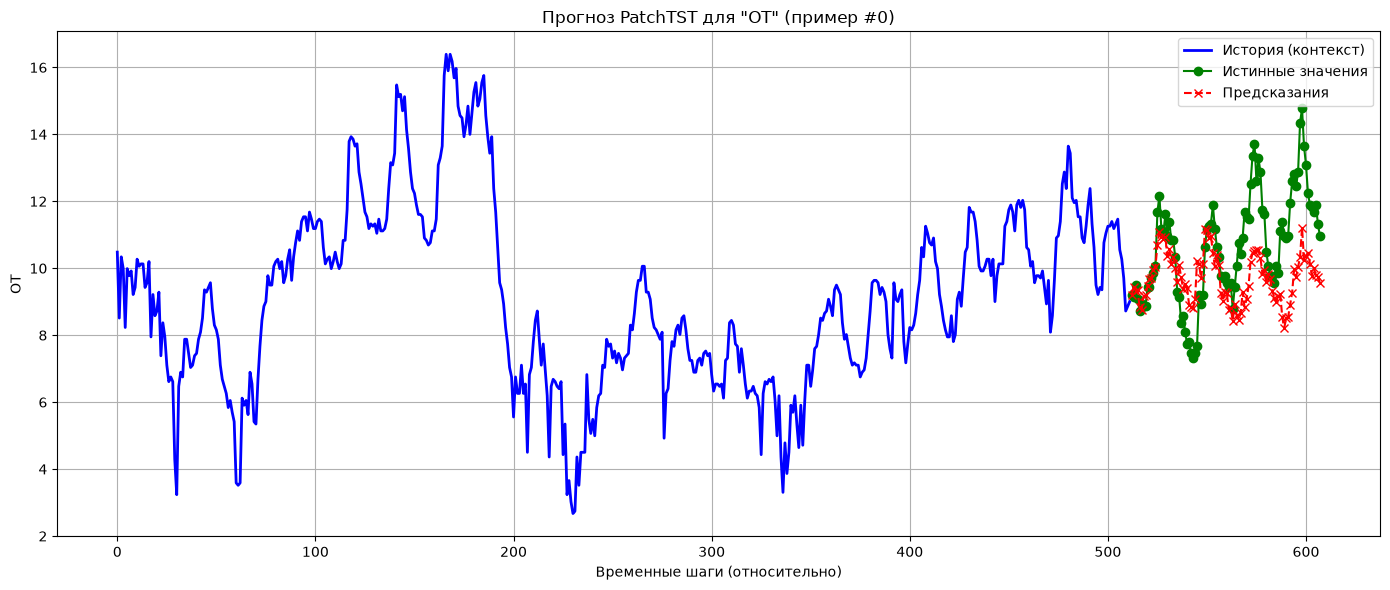


Вычисление RMSE на всём тестовом наборе...
RMSE (в исходных единицах) для каждого целевого столбца:
  HUFL: 5.1305
  HULL: 0.9724
  MUFL: 4.9367
  MULL: 0.8062
  LUFL: 0.7263
  LULL: 0.2160
  OT: 2.1011

Общий RMSE (по всем столбцам): 2.8605


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import mean_squared_error

# ------------------------------------------------------------------
# 1. Получаем предсказания на тестовой выборке
# ------------------------------------------------------------------
print("\nПолучение предсказаний на тестовом наборе...")
test_results = trainer.predict(test_dataset)

# Извлекаем предсказания (если это кортеж, берём первый элемент)
preds = test_results.predictions
if isinstance(preds, tuple):
    preds = preds[0]
print("Форма предсказаний:", preds.shape)  # (num_samples, forecast_horizon, num_features)

# ------------------------------------------------------------------
# 2. Получаем скалер (общий для всех целевых столбцов)
# ------------------------------------------------------------------
scaler = list(tsp.target_scaler_dict.values())[0]
print("Скалер успешно получен")

# ------------------------------------------------------------------
# 3. Вспомогательная функция для преобразования в numpy
# ------------------------------------------------------------------
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.numpy()
    return np.array(x)

# ------------------------------------------------------------------
# 4. Визуализация одного примера (можно менять idx)
# ------------------------------------------------------------------
idx = 0  # выберите любой индекс от 0 до len(test_dataset)-1

sample = test_dataset[idx]
context = to_numpy(sample['past_values'])      # (context_length, num_features)
true_future = to_numpy(sample['future_values']) # (forecast_horizon, num_features)
pred_future = preds[idx]                        # (forecast_horizon, num_features)

# Убедимся, что форма правильная
context = context.reshape(-1, len(forecast_columns))
true_future = true_future.reshape(-1, len(forecast_columns))
pred_future = pred_future.reshape(-1, len(forecast_columns))

# Инвертируем масштабирование для всех признаков
context_inv = scaler.inverse_transform(context)
true_inv = scaler.inverse_transform(true_future)
pred_inv = scaler.inverse_transform(pred_future)

# Выбираем столбец для визуализации (например, "OT")
col_name = "OT"
col_idx = forecast_columns.index(col_name)

# ------------------------------------------------------------------
# 5. Построение графика
# ------------------------------------------------------------------
plt.figure(figsize=(14, 6))

x_context = np.arange(context_length)
x_future = np.arange(context_length, context_length + forecast_horizon)

plt.plot(x_context, context_inv[:, col_idx], label='История (контекст)', color='blue', linewidth=2)
plt.plot(x_future, true_inv[:, col_idx], label='Истинные значения', color='green', marker='o', linestyle='-', linewidth=1.5)
plt.plot(x_future, pred_inv[:, col_idx], label='Предсказания', color='red', marker='x', linestyle='--', linewidth=1.5)

plt.xlabel('Временные шаги (относительно)')
plt.ylabel(col_name)
plt.title(f'Прогноз PatchTST для "{col_name}" (пример #{idx})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 6. Оценка точности на всех тестовых данных (RMSE в исходных единицах)
# ------------------------------------------------------------------
print("\nВычисление RMSE на всём тестовом наборе...")

# Собираем все истинные и предсказанные значения (для всех примеров)
all_true = []
all_pred = []

for i in range(len(test_dataset)):
    sample_i = test_dataset[i]
    true_i = to_numpy(sample_i['future_values']).reshape(-1, len(forecast_columns))
    pred_i = preds[i].reshape(-1, len(forecast_columns))
    
    all_true.append(true_i)
    all_pred.append(pred_i)

all_true = np.vstack(all_true)   # (total_samples, num_features)
all_pred = np.vstack(all_pred)

# Инвертируем масштабирование для всего массива
all_true_inv = scaler.inverse_transform(all_true)
all_pred_inv = scaler.inverse_transform(all_pred)

# Вычисляем RMSE для каждого столбца
rmse_per_column = {}
for i, col in enumerate(forecast_columns):
    rmse = np.sqrt(mean_squared_error(all_true_inv[:, i], all_pred_inv[:, i]))
    rmse_per_column[col] = rmse

# Выводим результаты
print("RMSE (в исходных единицах) для каждого целевого столбца:")
for col, rmse in rmse_per_column.items():
    print(f"  {col}: {rmse:.4f}")

# Общий RMSE по всем столбцам (усреднённый)
overall_rmse = np.sqrt(np.mean((all_true_inv - all_pred_inv) ** 2))
print(f"\nОбщий RMSE (по всем столбцам): {overall_rmse:.4f}")

In [13]:
# Сохраняем модель и препроцессор
model.save_pretrained("./patchtst_etth1_model")
tsp.save_pretrained("./patchtst_etth1_preprocessor")

print("Модель и препроцессор сохранены в текущую директорию.")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 115.58it/s]
INFO:p-13608:t-26432:processor.py:save_pretrained:Feature extractor saved in ./patchtst_etth1_preprocessor\preprocessor_config.json


Модель и препроцессор сохранены в текущую директорию.


------------------------------------------------------------------------
